In [1]:
!pip -q install rdkit torch-geometric tqdm scikit-learn requests matplotlib chembl_webresource_client

In [ ]:
import torch

pt_version = torch.__version__.split('+')[0]

if torch.version.cuda is not None:
    device_version = 'cu' + torch.version.cuda.replace('.', '')
else:
    device_version = 'cpu'

print(f"PyTorch 버전: {pt_version}, 환경: {device_version}")

!pip install torch_geometric
!pip install pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{pt_version}+{device_version}.html

In [2]:
import os
import time
import random
import requests
import numpy as np
import pandas as pd

from urllib.parse import quote
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, average_precision_score

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

from torch_geometric.data import HeteroData
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import HANConv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

c:\miniconda3\envs\yeast\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cpu


In [3]:
# -----------------------------
# Real Data Loading
# -----------------------------
import pandas as pd
import os

# Check if CSV files exist
required_files = [
    "real_gene_metabolite_edges.csv", 
    "real_drug_target_edges.csv", 
    "real_target_disease_edges.csv"
]
for f in required_files:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing file: {f}. Please run generate_real_edges.py first.")

gene_metabolite_edges = pd.read_csv("real_gene_metabolite_edges.csv")
drug_target_edges = pd.read_csv("real_drug_target_edges.csv")
target_disease_edges = pd.read_csv("real_target_disease_edges.csv")

# Ensure column names are strictly matching expectations
# gene_metabolite_edges: gene_id, metabolite_name
# drug_target_edges: drug_name, target_id, confidence
# target_disease_edges: target_id, disease_id, disease_name, association_score

# -----------------------------
# Node tables
# -----------------------------

genes_df = pd.DataFrame({
    "gene_id": sorted(gene_metabolite_edges["gene_id"].astype(str).unique())
})

metabolites_df = pd.DataFrame({
    "metabolite_name": sorted(gene_metabolite_edges["metabolite_name"].astype(str).unique())
})

drugs_df = pd.DataFrame({
    "drug_name": sorted(drug_target_edges["drug_name"].astype(str).unique())
})

targets_df = pd.DataFrame({
    "target_id": sorted(
        set(drug_target_edges["target_id"].astype(str)) | set(target_disease_edges["target_id"].astype(str))
    )
})

diseases_df = pd.DataFrame({
    "disease_id": sorted(target_disease_edges["disease_id"].astype(str).unique()),
    "disease_name": sorted(target_disease_edges["disease_name"].astype(str).unique())
})

print("genes:", genes_df.shape)
print("metabolites:", metabolites_df.shape)
print("drugs:", drugs_df.shape)
print("targets:", targets_df.shape)
print("diseases:", diseases_df.shape)

display(gene_metabolite_edges.head(5))
display(drug_target_edges.head(5))
display(target_disease_edges.head(5))

genes: (6, 1)
metabolites: (10, 1)
drugs: (150, 1)
targets: (54, 1)
diseases: (1, 2)


,gene_id,metabolite_name
0,ADE6,5'-Phosphoribosyl-N-formylglycinamide
1,ADE8,5'-Phosphoribosyl-N-formylglycinamide
2,ADE2,5'-Phosphoribosyl-N-formylglycinamide
3,CRD1,CL(10:0/14:1(11Z)/22:0/24:0)
4,CRD1,CL(10:0/16:1(9Z)/16:1(11Z)/18:1(9Z))


,drug_name,target_id,confidence
0,CHEMBL146794,AR,0.95
1,CHEMBL2112885,AR,0.95
2,CHEMBL717,AR,0.95
3,CHEMBL103,AR,0.95
4,CHEMBL1274,AR,0.95


,target_id,disease_id,disease_name,association_score
0,SLC35A2,ALOPECIA,Alopecia,0.041922
1,CXCL8,ALOPECIA,Alopecia,0.040448
2,KLRC2,ALOPECIA,Alopecia,0.036958
3,HSPD1,ALOPECIA,Alopecia,0.031605
4,HSPA14,ALOPECIA,Alopecia,0.031466


In [4]:
import time
import requests
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.parse import quote
from tqdm.auto import tqdm

def fetch_single_smiles(compound_name):
    """
    화합물 이름이 CHEMBL ID인 경우 ChEMBL API를, 일반 이름인 경우 PubChem API를 사용하여 SMILES를 조회합니다.
    """
    if compound_name.upper().startswith("CHEMBL"):
        url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/{compound_name.upper()}.json"
        try:
            r = requests.get(url, timeout=10)
            if r.status_code == 200:
                data = r.json()
                structs = data.get("molecule_structures")
                if structs and isinstance(structs, dict):
                    smiles = structs.get("canonical_smiles") or structs.get("standard_smiles")
                    if smiles:
                        return compound_name, smiles
        except Exception:
            pass
            
    # 일반 이름인 경우 PubChem API 사용
    safe_name = quote(compound_name)
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{safe_name}/property/CanonicalSMILES,IsomericSMILES/JSON"
    
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            data = r.json()
            props = data.get("PropertyTable", {}).get("Properties", [])
            if props:
                smiles = props[0].get("CanonicalSMILES") or props[0].get("SMILES") or props[0].get("IsomericSMILES") or props[0].get("ConnectivitySMILES")
                if smiles:
                    return compound_name, smiles
    except Exception:
        pass
        
    return compound_name, None

def fetch_smiles_concurrently(compound_list, max_workers=10):
    """
    주어진 화합물 리스트를 멀티스레딩으로 매우 빠르게 조회합니다.
    """
    unique_names = list(set(compound_list))
    results = []
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(fetch_single_smiles, name): name for name in unique_names}
        
        for future in tqdm(as_completed(futures), total=len(futures), desc="Fetching SMILES"):
            name, smiles = future.result()
            results.append({"Name": name, "smiles": smiles})
            time.sleep(0.05)
            
    df = pd.DataFrame(results)
    return df

# 중복 없는 전체 화합물 이름 추출
all_metabolites = metabolites_df["metabolite_name"].tolist()
all_drugs = drugs_df["drug_name"].tolist()

print(f"Total unique metabolites to fetch: {len(set(all_metabolites))}")
print("--- Fetching Metabolite SMILES ---")
metabolite_smiles_df = fetch_smiles_concurrently(all_metabolites, max_workers=15)

print(f"Total unique drugs to fetch: {len(set(all_drugs))}")
print("--- Fetching Drug SMILES ---")
drug_smiles_df = fetch_smiles_concurrently(all_drugs, max_workers=15)

# 원본 데이터프레임과 병합
metabolite_smiles_df['merge_name'] = metabolite_smiles_df['Name'].str.lower()
metabolites_df['merge_name'] = metabolites_df['metabolite_name'].str.lower()
metabolites_df = metabolites_df.merge(metabolite_smiles_df[['merge_name', 'smiles']], on='merge_name', how='left').drop(columns=['merge_name'])

drug_smiles_df['merge_name'] = drug_smiles_df['Name'].str.lower()
drugs_df['merge_name'] = drugs_df['drug_name'].str.lower()
drugs_df = drugs_df.merge(drug_smiles_df[['merge_name', 'smiles']], on='merge_name', how='left').drop(columns=['merge_name'])

# 추출된 비율 출력
print(f"Metabolites with SMILES: {metabolites_df['smiles'].notna().sum()} / {len(metabolites_df)}")
print(f"Drugs with SMILES: {drugs_df['smiles'].notna().sum()} / {len(drugs_df)}")

display(metabolites_df.head(10))
display(drugs_df.head(10))

Total unique metabolites to fetch: 10
--- Fetching Metabolite SMILES ---


Fetching SMILES:   0%|          | 0/10 [00:00<?, ?it/s]

Fetching SMILES: 100%|██████████| 10/10 [00:01<00:00,  6.27it/s]


Total unique drugs to fetch: 150
--- Fetching Drug SMILES ---


Fetching SMILES: 100%|██████████| 150/150 [00:39<00:00,  3.79it/s]

Metabolites with SMILES: 2 / 10
Drugs with SMILES: 150 / 150


,metabolite_name,smiles
0,(3R)-hydroxytetracosanoyl-CoA,CCCCCCCCCCCCCCCCCCCCC[C@H](CC(=O)SCCNC(=O)CCNC...
1,5'-Phosphoribosyl-N-formylglycinamide,C([C@@H]1[C@H]([C@H]([C@@H](O1)NC(=O)CNC=O)O)O...
2,CDP-DG(15:1(9Z)/24:1(11Z)),NaN
3,CL(10:0/14:1(11Z)/22:0/24:0),NaN
4,CL(10:0/16:1(9Z)/16:1(11Z)/18:1(9Z)),NaN
5,CL(12:0/14:1(11Z)/16:1(9Z)/30:0),NaN
6,CL(12:0/16:1(9Z)/18:1(9Z)/18:1(9Z)),NaN
7,CL(14:0/15:1(11Z)/18:1(9Z)/25:0),NaN
8,CL(14:1(11Z)/15:1(11Z)/18:0/23:1(11Z)),NaN
9,CL(14:1(9Z)/15:1(11Z)/15:1(9Z)/24:1(11Z)),NaN


,drug_name,smiles
0,CHEMBL101253,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1
1,CHEMBL101683,O=C(Nc1ccc(Cl)cc1)c1ccccc1NCc1ccncc1
2,CHEMBL102346,COc1cc2ncnc(N3CCN(C(=O)Nc4ccc(Oc5ccccc5)cc4)CC...
3,CHEMBL103,CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...
4,CHEMBL104067,COc1cc2ncnc(N3CCN(C(=O)Nc4ccc(C(C)C)cc4)CC3)c2...
5,CHEMBL106966,COc1cc2ncnc(N3CCN(C(=O)Nc4ccc(C#N)cc4)CC3)c2cc1OC
6,CHEMBL107599,COc1cc2c(N3CCN(C(=O)Nc4ccc(OC(C)C)cc4)CC3)ncnc...
7,CHEMBL115220,O=C(Cc1ccc2ccccc2c1)Nc1cc(C2CC2)n[nH]1
8,CHEMBL124035,COCCOc1cc2ncnc(N3CCN(C(=O)Nc4ccc(OC(C)C)cc4)CC...
9,CHEMBL124660,COc1cc2c(N3CCN(C(=O)Nc4ccc(OC(C)C)cc4)CC3)ncnc...


In [5]:
metabolites_df = metabolites_df.dropna(subset=["smiles"]).reset_index(drop=True)
drugs_df = drugs_df.dropna(subset=["smiles"]).reset_index(drop=True)

# gene-metabolite edge도 살아남은 metabolite만 유지
gene_metabolite_edges = gene_metabolite_edges[
    gene_metabolite_edges["metabolite_name"].isin(metabolites_df["metabolite_name"])
].reset_index(drop=True)

# drug-target edge도 살아남은 drug만 유지
drug_target_edges = drug_target_edges[
    drug_target_edges["drug_name"].isin(drugs_df["drug_name"])
].reset_index(drop=True)

print("After SMILES filtering")
print("metabolites:", metabolites_df.shape)
print("drugs:", drugs_df.shape)
print("gene-metabolite edges:", gene_metabolite_edges.shape)
print("drug-target edges:", drug_target_edges.shape)

After SMILES filtering
metabolites: (2, 2)
drugs: (150, 2)
gene-metabolite edges: (5, 2)
drug-target edges: (150, 3)


In [6]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    mol = Chem.MolFromSmiles(str(smiles))
    return mol

def smiles_to_fp(smiles):
    mol = smiles_to_mol(smiles)
    if mol is None:
        return None
    return morgan_generator.GetFingerprint(mol)

metabolites_df["mol"] = metabolites_df["smiles"].apply(smiles_to_mol)
metabolites_df["fp"] = metabolites_df["smiles"].apply(smiles_to_fp)

drugs_df["mol"] = drugs_df["smiles"].apply(smiles_to_mol)
drugs_df["fp"] = drugs_df["smiles"].apply(smiles_to_fp)

metabolites_df = metabolites_df[metabolites_df["fp"].notna()].reset_index(drop=True)
drugs_df = drugs_df[drugs_df["fp"].notna()].reset_index(drop=True)

print("valid metabolites:", len(metabolites_df))
print("valid drugs:", len(drugs_df))

valid metabolites: 2
valid drugs: 150


In [7]:
TOP_K = 5

sim_rows = []

drug_names = drugs_df["drug_name"].tolist()
drug_fps = drugs_df["fp"].tolist()

for met_row in tqdm(metabolites_df.itertuples(index=False), total=len(metabolites_df)):
    met_name = met_row.metabolite_name
    met_fp = met_row.fp

    sims = DataStructs.BulkTanimotoSimilarity(met_fp, drug_fps)
    top_idx = np.argsort(sims)[::-1][:TOP_K]

    for j in top_idx:
        sim_rows.append({
            "metabolite_name": met_name,
            "drug_name": drug_names[j],
            "tanimoto": float(sims[j])
        })

metabolite_drug_edges = pd.DataFrame(sim_rows)

print("Metabolite-Drug similarity edges:", metabolite_drug_edges.shape)

display(
    metabolite_drug_edges
    .sort_values("tanimoto", ascending=False)
    .head(50)
)

100%|██████████| 2/2 [00:00<00:00, 3794.03it/s]

Metabolite-Drug similarity edges: (10, 3)


,metabolite_name,drug_name,tanimoto
0,(3R)-hydroxytetracosanoyl-CoA,CHEMBL125898,0.128378
1,(3R)-hydroxytetracosanoyl-CoA,CHEMBL445636,0.128378
2,(3R)-hydroxytetracosanoyl-CoA,CHEMBL124035,0.127660
3,(3R)-hydroxytetracosanoyl-CoA,CHEMBL330863,0.127517
4,(3R)-hydroxytetracosanoyl-CoA,CHEMBL126699,0.125828
5,5'-Phosphoribosyl-N-formylglycinamide,CHEMBL1642357,0.094118
6,5'-Phosphoribosyl-N-formylglycinamide,CHEMBL77650,0.093750
7,5'-Phosphoribosyl-N-formylglycinamide,CHEMBL115220,0.093333
8,5'-Phosphoribosyl-N-formylglycinamide,CHEMBL1642361,0.093023
9,5'-Phosphoribosyl-N-formylglycinamide,CHEMBL1642358,0.091954


In [8]:
def make_mapping(values):
    values = sorted(pd.Series(values).dropna().astype(str).unique().tolist())
    id2idx = {v: i for i, v in enumerate(values)}
    idx2id = {i: v for v, i in id2idx.items()}
    return id2idx, idx2id

gene2idx, idx2gene = make_mapping(genes_df["gene_id"])
met2idx, idx2met = make_mapping(metabolites_df["metabolite_name"])
drug2idx, idx2drug = make_mapping(drugs_df["drug_name"])
target2idx, idx2target = make_mapping(targets_df["target_id"])
disease2idx, idx2disease = make_mapping(diseases_df["disease_id"])

print("gene:", len(gene2idx))
print("metabolite:", len(met2idx))
print("drug:", len(drug2idx))
print("target:", len(target2idx))
print("disease:", len(disease2idx))

gene: 6
metabolite: 2
drug: 150
target: 54
disease: 1


In [10]:
def build_edge_index(df, src_col, dst_col, src_map, dst_map):
    src_list = []
    dst_list = []

    for _, row in df.iterrows():
        s = str(row[src_col])
        d = str(row[dst_col])

        if s in src_map and d in dst_map:
            src_list.append(src_map[s])
            dst_list.append(dst_map[d])

    if len(src_list) == 0:
        return torch.empty((2, 0), dtype=torch.long)

    return torch.tensor([src_list, dst_list], dtype=torch.long)


data = HeteroData()

data["gene"].num_nodes = len(gene2idx)
data["metabolite"].num_nodes = len(met2idx)
data["drug"].num_nodes = len(drug2idx)
data["target"].num_nodes = len(target2idx)
data["disease"].num_nodes = len(disease2idx)


# Gene -> Metabolite
gm_edge = build_edge_index(
    gene_metabolite_edges,
    "gene_id",
    "metabolite_name",
    gene2idx,
    met2idx
)

data["gene", "produces", "metabolite"].edge_index = gm_edge
data["metabolite", "rev_produces", "gene"].edge_index = gm_edge.flip(0)


# Metabolite -> Drug
md_edge = build_edge_index(
    metabolite_drug_edges,
    "metabolite_name",
    "drug_name",
    met2idx,
    drug2idx
)

data["metabolite", "similar_to", "drug"].edge_index = md_edge
data["drug", "rev_similar_to", "metabolite"].edge_index = md_edge.flip(0)


# Drug -> Target
dt_edge = build_edge_index(
    drug_target_edges,
    "drug_name",
    "target_id",
    drug2idx,
    target2idx
)

data["drug", "inhibits", "target"].edge_index = dt_edge
data["target", "rev_inhibits", "drug"].edge_index = dt_edge.flip(0)


# Target -> Disease
td_edge = build_edge_index(
    target_disease_edges,
    "target_id",
    "disease_id",
    target2idx,
    disease2idx
)

data["target", "associated_with", "disease"].edge_index = td_edge
data["disease", "rev_associated_with", "target"].edge_index = td_edge.flip(0)


print(data)
print(data.metadata())

HeteroData(
  gene={ num_nodes=6 },
  metabolite={ num_nodes=2 },
  drug={ num_nodes=150 },
  target={ num_nodes=54 },
  disease={ num_nodes=1 },
  (gene, produces, metabolite)={ edge_index=[2, 5] },
  (metabolite, rev_produces, gene)={ edge_index=[2, 5] },
  (metabolite, similar_to, drug)={ edge_index=[2, 10] },
  (drug, rev_similar_to, metabolite)={ edge_index=[2, 10] },
  (drug, inhibits, target)={ edge_index=[2, 150] },
  (target, rev_inhibits, drug)={ edge_index=[2, 150] },
  (target, associated_with, disease)={ edge_index=[2, 50] },
  (disease, rev_associated_with, target)={ edge_index=[2, 50] }
)
(['gene', 'metabolite', 'drug', 'target', 'disease'], [('gene', 'produces', 'metabolite'), ('metabolite', 'rev_produces', 'gene'), ('metabolite', 'similar_to', 'drug'), ('drug', 'rev_similar_to', 'metabolite'), ('drug', 'inhibits', 'target'), ('target', 'rev_inhibits', 'drug'), ('target', 'associated_with', 'disease'), ('disease', 'rev_associated_with', 'target')])


In [11]:
# Convert RDKit fingerprints to tensors and assign them as node features
import numpy as np
import torch

def fp_to_tensor(fp):
    arr = np.zeros((0,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return torch.tensor(arr, dtype=torch.float)

drug_x = torch.stack([fp_to_tensor(fp) for fp in drugs_df["fp"]])
metabolite_x = torch.stack([fp_to_tensor(fp) for fp in metabolites_df["fp"]])

data["drug"].x = drug_x
data["metabolite"].x = metabolite_x

# For gene, target, disease, assign constant features (size 1)
data["gene"].x = torch.ones((data["gene"].num_nodes, 1), dtype=torch.float)
data["target"].x = torch.ones((data["target"].num_nodes, 1), dtype=torch.float)
data["disease"].x = torch.ones((data["disease"].num_nodes, 1), dtype=torch.float)

print("drug x shape:", data["drug"].x.shape)
print("metabolite x shape:", data["metabolite"].x.shape)
print("gene x shape:", data["gene"].x.shape)

drug x shape: torch.Size([150, 2048])
metabolite x shape: torch.Size([2, 2048])
gene x shape: torch.Size([6, 1])


In [12]:
TASK_EDGE_TYPES = [
    ("metabolite", "similar_to", "drug"),
    ("drug", "inhibits", "target"),
]

REV_EDGE_TYPES = [
    ("drug", "rev_similar_to", "metabolite"),
    ("target", "rev_inhibits", "drug"),
]

transform = RandomLinkSplit(
    num_val=0.2,
    num_test=0.2,
    is_undirected=False,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
    edge_types=TASK_EDGE_TYPES,
    rev_edge_types=REV_EDGE_TYPES,
)

train_data, val_data, test_data = transform(data)




# -----------------------------
# Minibatch DataLoaders (LinkNeighborLoader)
# -----------------------------
from torch_geometric.loader import LinkNeighborLoader

# For training, we need multiple edge types to supervise.
# PyTorch Geometric's LinkNeighborLoader natively supports edge_label_index as a single tuple.
# So we create a list of loaders, one for each target edge type.
train_loader = []
for edge_type in TASK_EDGE_TYPES:
    if edge_type in train_data.edge_types and hasattr(train_data[edge_type], 'edge_label_index'):
        train_loader.append(
            LinkNeighborLoader(
                train_data,
                num_neighbors=[10, 5],
                edge_label_index=(edge_type, train_data[edge_type].edge_label_index),
                edge_label=train_data[edge_type].edge_label,
                batch_size=128,
                shuffle=True,
                neg_sampling_ratio=1.0,
            )
        )

val_loader = []
for edge_type in TASK_EDGE_TYPES:
    if edge_type in val_data.edge_types and hasattr(val_data[edge_type], 'edge_label_index'):
        val_loader.append(
            LinkNeighborLoader(
                val_data,
                num_neighbors=[10, 5],
                edge_label_index=(edge_type, val_data[edge_type].edge_label_index),
                edge_label=val_data[edge_type].edge_label,
                batch_size=128,
                shuffle=False,
            )
        )

test_loader = []
for edge_type in TASK_EDGE_TYPES:
    if edge_type in test_data.edge_types and hasattr(test_data[edge_type], 'edge_label_index'):
        test_loader.append(
            LinkNeighborLoader(
                test_data,
                num_neighbors=[10, 5],
                edge_label_index=(edge_type, test_data[edge_type].edge_label_index),
                edge_label=test_data[edge_type].edge_label,
                batch_size=128,
                shuffle=False,
            )
        )

In [13]:
class InductiveHANLinkPredictor(nn.Module):
    def __init__(self, metadata, in_channels_dict, hidden_channels=64, out_channels=64, heads=4, dropout=0.1):
        super().__init__()
        self.node_proj = nn.ModuleDict({
            node_type: nn.Linear(in_channels, hidden_channels)
            for node_type, in_channels in in_channels_dict.items()
        })
        self.conv1 = HANConv(hidden_channels, hidden_channels, metadata=metadata, heads=heads, dropout=dropout)
        self.conv2 = HANConv(hidden_channels, out_channels, metadata=metadata, heads=heads, dropout=dropout)

    def forward(self, data):
        # 1. 초기 Feature Projection (Morgan Fingerprint -> 64차원)
        x_dict_proj = {
            node_type: self.node_proj[node_type](x)
            for node_type, x in data.x_dict.items()
        }

        # 2. First Layer + 잔차 연결(Residual Connection)
        out1 = self.conv1(x_dict_proj, data.edge_index_dict)
        x_dict = {}
        for k in x_dict_proj.keys():
            conv_out = out1.get(k)
            if conv_out is not None:
                # GNN 메시지 패싱 결과에 본래 자신의 Feature를 더해줌 (+)
                x_dict[k] = F.elu(conv_out + x_dict_proj[k]) 
            else:
                x_dict[k] = F.elu(x_dict_proj[k])

        # 3. Second Layer + 잔차 연결
        out2 = self.conv2(x_dict, data.edge_index_dict)
        final_dict = {}
        for k in x_dict.keys():
            conv_out = out2.get(k)
            if conv_out is not None:
                # 최종 레이어는 F.elu 없이 Linear 조합
                final_dict[k] = conv_out + x_dict[k]
            else:
                final_dict[k] = x_dict[k]

        return final_dict

    def decode(self, z_dict, edge_label_index, src_type, dst_type):
        src_z = z_dict[src_type][edge_label_index[0]]
        dst_z = z_dict[dst_type][edge_label_index[1]]
        logits = (src_z * dst_z).sum(dim=-1)
        return logits

In [14]:
in_channels_dict = {
    node_type: data[node_type].x.size(-1)
    for node_type in data.node_types
}

model = InductiveHANLinkPredictor(
    metadata=data.metadata(),
    in_channels_dict=in_channels_dict,
    hidden_channels=64,
    out_channels=64,
    heads=4,
    dropout=0.1,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4,
)


print(model)

InductiveHANLinkPredictor(
  (node_proj): ModuleDict(
    (gene): Linear(in_features=1, out_features=64, bias=True)
    (metabolite): Linear(in_features=2048, out_features=64, bias=True)
    (drug): Linear(in_features=2048, out_features=64, bias=True)
    (target): Linear(in_features=1, out_features=64, bias=True)
    (disease): Linear(in_features=1, out_features=64, bias=True)
  )
  (conv1): HANConv(64, heads=4)
  (conv2): HANConv(64, heads=4)
)


In [16]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from collections import defaultdict
import numpy as np
import torch

@torch.no_grad()
def evaluate_auc_ap(model, loaders, edge_types, device):
    model.eval()
    
    y_true_dict = defaultdict(list)
    y_prob_dict = defaultdict(list)

    for loader, edge_type in zip(loaders, edge_types):
        for batch in loader:
            batch = batch.to(device)
            z_dict = model(batch)

            if edge_type not in batch.edge_types or not hasattr(batch[edge_type], 'edge_label_index'):
                continue
                
            src_type, rel_type, dst_type = edge_type
            edge_label_index = batch[edge_type].edge_label_index
            edge_label = batch[edge_type].edge_label.float()

            logits = model.decode(z_dict, edge_label_index, src_type, dst_type)
            probs = torch.sigmoid(logits).cpu().numpy()
            labels = edge_label.cpu().numpy()
            
            y_true_dict[edge_type].extend(labels)
            y_prob_dict[edge_type].extend(probs)

    results = {}
    for edge_type in edge_types:
        if edge_type not in y_true_dict or len(y_true_dict[edge_type]) == 0:
            continue
            
        y_true = np.array(y_true_dict[edge_type])
        probs = np.array(y_prob_dict[edge_type])

        if len(np.unique(y_true)) < 2:
            auc, ap, f1 = np.nan, np.nan, np.nan
        else:
            auc = roc_auc_score(y_true, probs)
            ap = average_precision_score(y_true, probs)
            preds = (probs > 0.5).astype(int)
            f1 = f1_score(y_true, preds, zero_division=0)

        results[edge_type] = {"AUC": auc, "AP": ap, "F1": f1}

    return results

def compute_loss(model, batch, task_edge_types):
    z_dict = model(batch)
    losses = []

    for edge_type in task_edge_types:
        if edge_type not in batch.edge_types or not hasattr(batch[edge_type], 'edge_label_index'):
            continue
            
        src_type, rel_type, dst_type = edge_type
        edge_label_index = batch[edge_type].edge_label_index
        edge_label = batch[edge_type].edge_label.float()

        logits = model.decode(z_dict, edge_label_index, src_type, dst_type)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, edge_label)
        losses.append(loss)

    if not losses:
        # If batch doesn't contain any target edges, return 0 with requires_grad
        return torch.tensor(0.0, device=z_dict[list(z_dict.keys())[0]].device, requires_grad=True)
        
    return sum(losses) / len(losses)

Epoch 005 | Loss 0.0000 | Val mean AP 0.7411 | Val mean F1 0.6790
  ('metabolite', 'similar_to', 'drug'): AUC=1.0000, AP=1.0000, F1=0.6667
  ('drug', 'inhibits', 'target'): AUC=0.4867, AP=0.4822, F1=0.6914
Epoch 010 | Loss 0.1760 | Val mean AP 0.8043 | Val mean F1 0.6933
  ('metabolite', 'similar_to', 'drug'): AUC=1.0000, AP=1.0000, F1=0.6667
  ('drug', 'inhibits', 'target'): AUC=0.6800, AP=0.6087, F1=0.7200
Epoch 015 | Loss 0.0000 | Val mean AP 0.8040 | Val mean F1 0.6933
  ('metabolite', 'similar_to', 'drug'): AUC=1.0000, AP=1.0000, F1=0.6667
  ('drug', 'inhibits', 'target'): AUC=0.6789, AP=0.6081, F1=0.7200
Epoch 020 | Loss 0.0000 | Val mean AP 0.8441 | Val mean F1 0.7136
  ('metabolite', 'similar_to', 'drug'): AUC=1.0000, AP=1.0000, F1=0.6667
  ('drug', 'inhibits', 'target'): AUC=0.7733, AP=0.6882, F1=0.7606
Epoch 025 | Loss 0.0000 | Val mean AP 0.8439 | Val mean F1 0.7136
  ('metabolite', 'similar_to', 'drug'): AUC=1.0000, AP=1.0000, F1=0.6667
  ('drug', 'inhibits', 'target'): AUC

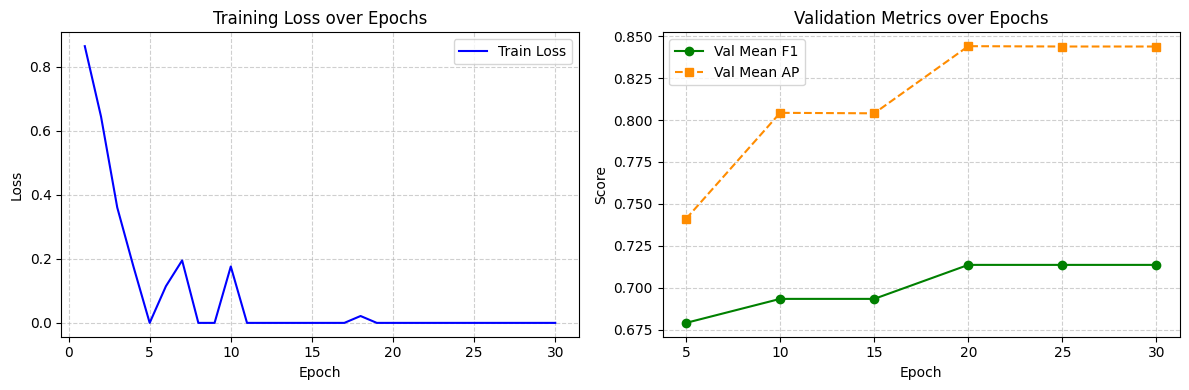

In [18]:
import matplotlib.pyplot as plt
import numpy as np

EPOCHS = 30 # Reduced for minibatch speed

best_val_ap = -1
best_state = None

history = {
    "train_loss": [],
    "val_mean_ap": [],
    "val_mean_f1": []
}

valid_train_edge_types = [et for et in TASK_EDGE_TYPES if et in train_data.edge_types and hasattr(train_data[et], 'edge_label_index')]
valid_val_edge_types = [et for et in TASK_EDGE_TYPES if et in val_data.edge_types and hasattr(val_data[et], 'edge_label_index')]

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    num_batches = 0
    
    iterators = [(etype, iter(loader)) for etype, loader in zip(valid_train_edge_types, train_loader)]
    active_iterators = iterators[:]
    
    while active_iterators:
        etype, it = active_iterators.pop(0)
        try:
            batch = next(it)
            active_iterators.append((etype, it))
        except StopIteration:
            continue
            
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        loss = compute_loss(model, batch, [etype])
        
        if loss.item() > 0:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1
            
    avg_loss = total_loss / max(1, num_batches)
    history["train_loss"].append(avg_loss)

    if epoch % 5 == 0:
        val_result = evaluate_auc_ap(model, val_loader, valid_val_edge_types, DEVICE)
        if not val_result: continue
        
        mean_val_ap = np.nanmean([v["AP"] for v in val_result.values()])
        mean_val_f1 = np.nanmean([v["F1"] for v in val_result.values()])

        if mean_val_ap > best_val_ap:
            best_val_ap = mean_val_ap
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(f"Epoch {epoch:03d} | Loss {avg_loss:.4f} | Val mean AP {mean_val_ap:.4f} | Val mean F1 {mean_val_f1:.4f}")
        for etype, metrics in val_result.items():
            print(f"  {etype}: AUC={metrics['AUC']:.4f}, AP={metrics['AP']:.4f}, F1={metrics['F1']:.4f}")
            
        history["val_mean_ap"].append((epoch, mean_val_ap))
        history["val_mean_f1"].append((epoch, mean_val_f1))

if best_state is not None:
    model.load_state_dict(best_state)

print("Training finished.")

# -------- Plotting Training Progress --------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history["train_loss"], label="Train Loss", color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
if history["val_mean_ap"]:
    val_epochs, val_aps = zip(*history["val_mean_ap"])
    val_epochs, val_f1s = zip(*history["val_mean_f1"])

    plt.plot(val_epochs, val_f1s, label="Val Mean F1", marker='o', color='green', linestyle='-')
    plt.plot(val_epochs, val_aps, label="Val Mean AP", marker='s', color='darkorange', linestyle='--')
    plt.title("Validation Metrics over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

In [19]:
@torch.no_grad()
def recall_at_k(model, batch_data, edge_type, k=3):
    model.eval()
    z_dict = model(batch_data)

    src_type, rel_type, dst_type = edge_type

    edge_label_index = batch_data[edge_type].edge_label_index
    edge_label = batch_data[edge_type].edge_label

    pos_edge_index = edge_label_index[:, edge_label == 1]

    if pos_edge_index.size(1) == 0:
        return np.nan

    dst_all = z_dict[dst_type]
    hits = 0

    for i in range(pos_edge_index.size(1)):
        src_idx = pos_edge_index[0, i]
        true_dst_idx = pos_edge_index[1, i]

        src_vec = z_dict[src_type][src_idx]
        scores = torch.matmul(dst_all, src_vec)

        topk = torch.topk(scores, k=min(k, dst_all.size(0))).indices

        if (topk == true_dst_idx).any():
            hits += 1

    return hits / pos_edge_index.size(1)


for k in [1, 2, 3]:
    r1 = recall_at_k(
        model,
        test_data,
        edge_type=("drug", "inhibits", "target"),
        k=k,
    )

    r2 = recall_at_k(
        model,
        test_data,
        edge_type=("metabolite", "similar_to", "drug"),
        k=k,
    )

    print(f"Drug-Target Recall@{k}: {r1:.4f}")
    print(f"Metabolite-Drug Recall@{k}: {r2:.4f}")

Drug-Target Recall@1: 0.3667
Metabolite-Drug Recall@1: 0.0000
Drug-Target Recall@2: 0.6667
Metabolite-Drug Recall@2: 0.0000
Drug-Target Recall@3: 0.8667
Metabolite-Drug Recall@3: 0.0000


In [20]:
@torch.no_grad()
def rank_genes_for_disease(model, full_data, disease_id="ALOPECIA", top_k=20):
    model.eval()

    full_data = full_data.to(DEVICE)
    z_dict = model(full_data)

    disease_idx = disease2idx[disease_id]
    disease_vec = z_dict["disease"][disease_idx]
    gene_mat = z_dict["gene"]

    logits = torch.matmul(gene_mat, disease_vec)
    probs = torch.sigmoid(logits)

    top = torch.topk(probs, k=min(top_k, probs.size(0)))

    rows = []
    for rank, (idx, score) in enumerate(
        zip(top.indices.cpu().tolist(), top.values.cpu().tolist()),
        start=1
    ):
        rows.append({
            "rank": rank,
            "gene_id": idx2gene[idx],
            "gnn_score": float(score)
        })

    return pd.DataFrame(rows)


gene_rank_df = rank_genes_for_disease(
    model,
    data,
    disease_id="ALOPECIA",
    top_k=20,
)

display(gene_rank_df)

,rank,gene_id,gnn_score
0,1,FOX2,0.986674
1,2,OAR1,0.986674
2,3,ADE2,0.960936
3,4,ADE6,0.960936
4,5,ADE8,0.960936
5,6,CRD1,0.495189


In [21]:
def build_path_explanation():
    rows = []

    for _, gm in gene_metabolite_edges.iterrows():
        gene = gm["gene_id"]
        met = gm["metabolite_name"]

        sim_hits = metabolite_drug_edges[
            metabolite_drug_edges["metabolite_name"] == met
        ]

        for _, sim in sim_hits.iterrows():
            drug = sim["drug_name"]
            tanimoto = sim["tanimoto"]

            dt_hits = drug_target_edges[
                drug_target_edges["drug_name"] == drug
            ]

            for _, dt in dt_hits.iterrows():
                target = dt["target_id"]
                dt_conf = dt["confidence"]

                td_hits = target_disease_edges[
                    target_disease_edges["target_id"] == target
                ]

                for _, td in td_hits.iterrows():
                    disease = td["disease_id"]
                    disease_score = td["association_score"]

                    path_score = tanimoto * dt_conf * disease_score

                    rows.append({
                        "gene_id": gene,
                        "metabolite": met,
                        "similar_drug": drug,
                        "target": target,
                        "disease": disease,
                        "tanimoto": tanimoto,
                        "drug_target_confidence": dt_conf,
                        "target_disease_score": disease_score,
                        "path_score": path_score,
                    })

    return pd.DataFrame(rows)


path_df = build_path_explanation()

display(
    path_df.sort_values("path_score", ascending=False).head(30)
)

KeyError: 'path_score'

In [20]:
# gene별 최고 path score
gene_path_score = (
    path_df
    .groupby("gene_id")["path_score"]
    .max()
    .reset_index()
)

# 0~1 scaling
if len(gene_path_score) > 0:
    max_path = gene_path_score["path_score"].max()
    if max_path > 0:
        gene_path_score["path_score_scaled"] = gene_path_score["path_score"] / max_path
    else:
        gene_path_score["path_score_scaled"] = 0.0
else:
    gene_path_score["path_score_scaled"] = 0.0

final_rank_df = gene_rank_df.merge(
    gene_path_score[["gene_id", "path_score", "path_score_scaled"]],
    on="gene_id",
    how="left"
)

final_rank_df["path_score"] = final_rank_df["path_score"].fillna(0)
final_rank_df["path_score_scaled"] = final_rank_df["path_score_scaled"].fillna(0)

final_rank_df["final_score"] = (
    0.5 * final_rank_df["gnn_score"]
    + 0.5 * final_rank_df["path_score_scaled"]
)

final_rank_df = final_rank_df.sort_values(
    "final_score",
    ascending=False
).reset_index(drop=True)

final_rank_df["final_rank"] = np.arange(1, len(final_rank_df) + 1)

display(final_rank_df[
    ["final_rank", "gene_id", "gnn_score", "path_score", "path_score_scaled", "final_score"]
])

,final_rank,gene_id,gnn_score,path_score,path_score_scaled,final_score
0,1,ERG11,1.000000,0.235897,1.000000,1.000000
1,2,ERG6,1.000000,0.235897,1.000000,1.000000
2,3,ERG24,1.000000,0.230000,0.975000,0.987500
3,4,ERG5,1.000000,0.227160,0.962963,0.981481
4,5,ERG4,1.000000,0.132558,0.561931,0.780965
5,6,ERG3,1.000000,0.132558,0.561931,0.780965
6,7,ERG2,1.000000,0.129545,0.549160,0.774580
7,8,ERG7,1.000000,0.115862,0.491154,0.745577
8,9,HMG2,0.999819,0.104516,0.443058,0.721438
9,10,HMG1,0.999819,0.104516,0.443058,0.721438


In [21]:
TOP_N = 5

for gene in final_rank_df["gene_id"].head(TOP_N):
    print("=" * 80)
    print(f"Gene: {gene}")

    gene_paths = path_df[path_df["gene_id"] == gene].sort_values(
        "path_score",
        ascending=False
    )

    if len(gene_paths) == 0:
        print("No interpretable path found.")
    else:
        display(gene_paths.head(5))

Gene: ERG11


,gene_id,metabolite,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
120,ERG11,cholesterol,epristeride,SRD5A2,ALOPECIA,0.294872,0.80,1.0,0.235897
122,ERG11,cholesterol,finasteride,SRD5A2,ALOPECIA,0.207317,0.95,1.0,0.196951
121,ERG11,cholesterol,clascoterone,AR,ALOPECIA,0.216867,0.80,0.9,0.156145
119,ERG11,cholesterol,abiraterone,CYP17A1,ALOPECIA,0.432836,0.90,0.4,0.155821
123,ERG11,cholesterol,finasteride,SRD5A1,ALOPECIA,0.207317,0.75,0.8,0.124390


Gene: ERG6


,gene_id,metabolite,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
132,ERG6,campesterol,epristeride,SRD5A2,ALOPECIA,0.294872,0.80,1.0,0.235897
138,ERG6,stigmasterol,epristeride,SRD5A2,ALOPECIA,0.280488,0.80,1.0,0.224390
134,ERG6,campesterol,finasteride,SRD5A2,ALOPECIA,0.207317,0.95,1.0,0.196951
140,ERG6,stigmasterol,finasteride,SRD5A2,ALOPECIA,0.197674,0.95,1.0,0.187791
139,ERG6,stigmasterol,clascoterone,AR,ALOPECIA,0.235294,0.80,0.9,0.169412


Gene: ERG24


,gene_id,metabolite,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
126,ERG24,desmosterol,epristeride,SRD5A2,ALOPECIA,0.287500,0.80,1.0,0.230000
129,ERG24,desmosterol,finasteride,SRD5A2,ALOPECIA,0.202381,0.95,1.0,0.192262
127,ERG24,desmosterol,clascoterone,AR,ALOPECIA,0.226190,0.80,0.9,0.162857
125,ERG24,desmosterol,abiraterone,CYP17A1,ALOPECIA,0.420290,0.90,0.4,0.151304
128,ERG24,desmosterol,spironolactone,AR,ALOPECIA,0.211765,0.70,0.9,0.133412


Gene: ERG5


,gene_id,metabolite,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
144,ERG5,beta-sitosterol,epristeride,SRD5A2,ALOPECIA,0.283951,0.80,1.0,0.227160
146,ERG5,beta-sitosterol,finasteride,SRD5A2,ALOPECIA,0.200000,0.95,1.0,0.190000
149,ERG5,beta-sitosterol,dutasteride,SRD5A2,ALOPECIA,0.185567,0.95,1.0,0.176289
145,ERG5,beta-sitosterol,clascoterone,AR,ALOPECIA,0.223529,0.80,0.9,0.160941
143,ERG5,beta-sitosterol,abiraterone,CYP17A1,ALOPECIA,0.434783,0.90,0.4,0.156522


Gene: ERG4


,gene_id,metabolite,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
117,ERG4,ergosterol,finasteride,SRD5A2,ALOPECIA,0.139535,0.95,1.0,0.132558
115,ERG4,ergosterol,epristeride,SRD5A2,ALOPECIA,0.149425,0.80,1.0,0.119540
116,ERG4,ergosterol,clascoterone,AR,ALOPECIA,0.149425,0.80,0.9,0.107586
114,ERG4,ergosterol,spironolactone,AR,ALOPECIA,0.149425,0.70,0.9,0.094138
113,ERG4,ergosterol,abiraterone,CYP17A1,ALOPECIA,0.250000,0.90,0.4,0.090000


In [22]:
@torch.no_grad()
def infer_new_drug(model, base_data, new_drug_smiles, target_edges=[], metabolite_edges=[]):
    """
    Introduce a completely new drug node based on its SMILES string.
    Calculate its embedding instantly and score it against all targets/metabolites.
    
    target_edges: List of target IDs the drug interacts with (for graph structure).
    metabolite_edges: List of metabolite names similar to this drug.
    """
    model.eval()
    
    # 1. Generate fingerprint for the new drug
    fp = smiles_to_fp(new_drug_smiles)
    if fp is None:
        raise ValueError("Invalid SMILES string")
        
    new_x = fp_to_tensor(fp).unsqueeze(0).to(DEVICE) # Shape: (1, 2048)
    
    # 2. Clone the base data to safely add the new node and its edges
    infer_data = base_data.clone().to(DEVICE)
    
    # The new node gets index `num_nodes`
    new_drug_idx = infer_data["drug"].num_nodes
    
    # Add to node features
    infer_data["drug"].x = torch.cat([infer_data["drug"].x, new_x], dim=0)
    
    # Add new edges if provided
    new_dt_src = []
    new_dt_dst = []
    for tgt in target_edges:
        if tgt in target2idx:
            new_dt_src.append(new_drug_idx)
            new_dt_dst.append(target2idx[tgt])
            
    if new_dt_src:
        new_edge = torch.tensor([new_dt_src, new_dt_dst], dtype=torch.long, device=DEVICE)
        dt_idx = infer_data["drug", "inhibits", "target"].edge_index
        infer_data["drug", "inhibits", "target"].edge_index = torch.cat([dt_idx, new_edge], dim=1)
        
        # Add reverse edges
        rev_dt_idx = infer_data["target", "rev_inhibits", "drug"].edge_index
        rev_new_edge = torch.tensor([new_dt_dst, new_dt_src], dtype=torch.long, device=DEVICE)
        infer_data["target", "rev_inhibits", "drug"].edge_index = torch.cat([rev_dt_idx, rev_new_edge], dim=1)
        
    new_md_src = []
    new_md_dst = []
    for met in metabolite_edges:
        if met in met2idx:
            new_md_src.append(met2idx[met])
            new_md_dst.append(new_drug_idx)
            
    if new_md_src:
        new_edge = torch.tensor([new_md_src, new_md_dst], dtype=torch.long, device=DEVICE)
        md_idx = infer_data["metabolite", "similar_to", "drug"].edge_index
        infer_data["metabolite", "similar_to", "drug"].edge_index = torch.cat([md_idx, new_edge], dim=1)
        
        # Add reverse edges
        rev_md_idx = infer_data["drug", "rev_similar_to", "metabolite"].edge_index
        rev_new_edge = torch.tensor([new_md_dst, new_md_src], dtype=torch.long, device=DEVICE)
        infer_data["drug", "rev_similar_to", "metabolite"].edge_index = torch.cat([rev_md_idx, rev_new_edge], dim=1)
        
    # 3. Perform a single forward pass
    z_dict = model(infer_data)
    new_drug_emb = z_dict["drug"][new_drug_idx]
    
    # 4. Score against all targets
    all_target_embs = z_dict["target"]
    target_scores = torch.matmul(all_target_embs, new_drug_emb)
    target_probs = torch.sigmoid(target_scores)
    
    top_targets = torch.topk(target_probs, k=5)
    
    print("New Drug Embedding extracted successfully. Shape:", new_drug_emb.shape)
    print("Top 5 Predicted Targets:")
    for score, idx in zip(top_targets.values, top_targets.indices):
        print(f" - {idx2target[idx.item()]}: {score.item():.4f}")

    return new_drug_emb, target_probs

# Let's test with a fictional drug (or an existing one not in the network)
# We use Ibuprofen SMILES as a test case
test_smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"
print("Testing inductive learning with new SMILES:", test_smiles)
emb, probs = infer_new_drug(model, data, test_smiles)

Testing inductive learning with new SMILES: CC(C)CC1=CC=C(C=C1)C(C)C(=O)O
New Drug Embedding extracted successfully. Shape: torch.Size([64])
Top 5 Predicted Targets:
 - HMGCR: 0.2242
 - KCNJ8: 0.1495
 - ESR1: 0.1385
 - SRD5A2: 0.0717
 - SRD5A1: 0.0699


Visualizing Link Prediction Performance on Test Data:


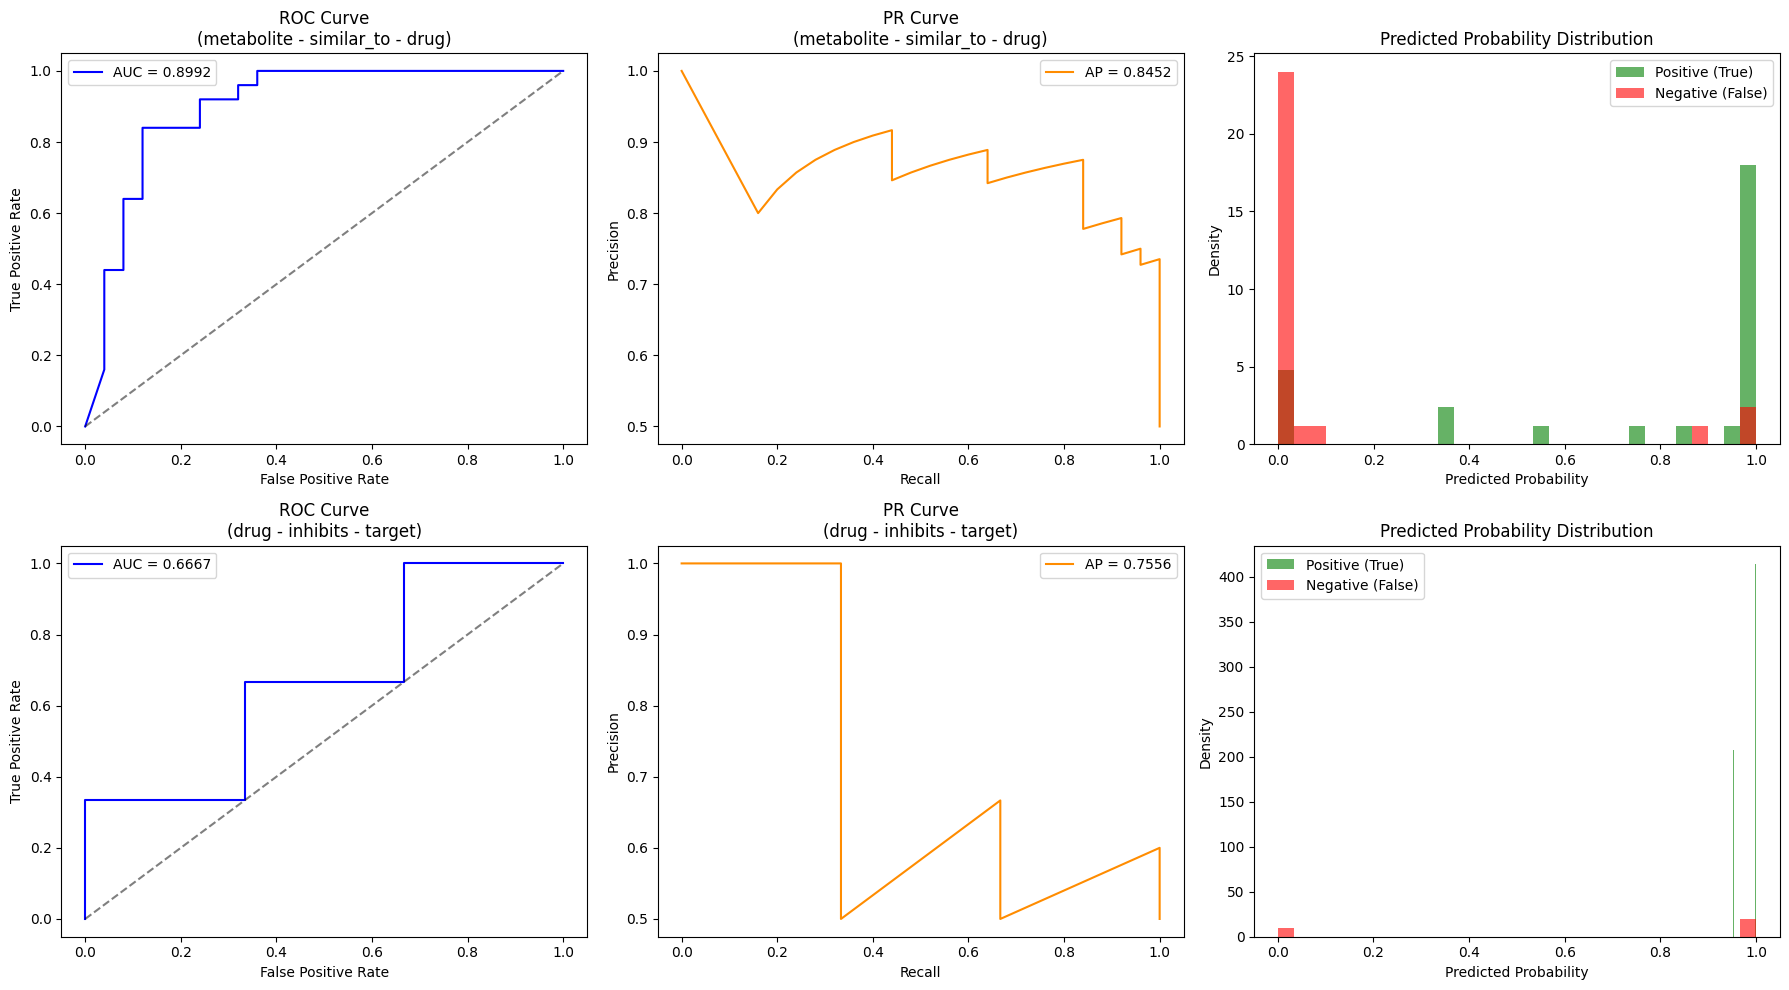

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import torch
import numpy as np

@torch.no_grad()
def plot_link_prediction_performance(model, loaders, edge_types, device="cpu"):
    model.eval()

    num_tasks = len(edge_types)
    fig, axes = plt.subplots(num_tasks, 2, figsize=(12, 5 * num_tasks))

    if num_tasks == 1:
        axes = [axes]

    for i, (loader, edge_type) in enumerate(zip(loaders, edge_types)):
        y_true_list = []
        y_prob_list = []
        
        for batch in loader:
            batch = batch.to(device)
            z_dict = model(batch)

            if edge_type not in batch.edge_types or not hasattr(batch[edge_type], 'edge_label_index'):
                continue
                
            src_type, rel_type, dst_type = edge_type
            edge_label_index = batch[edge_type].edge_label_index
            edge_label = batch[edge_type].edge_label.float()

            logits = model.decode(z_dict, edge_label_index, src_type, dst_type)
            probs = torch.sigmoid(logits).cpu().numpy()
            labels = edge_label.cpu().numpy()
            
            y_true_list.extend(labels)
            y_prob_list.extend(probs)
            
        if len(y_true_list) == 0:
            continue
            
        y_true = np.array(y_true_list)
        probs = np.array(y_prob_list)

        if len(np.unique(y_true)) < 2:
            continue

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_true, probs)
        roc_auc = auc(fpr, tpr)
        axes[i][0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        axes[i][0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[i][0].set_title(f'ROC Curve: {edge_type[1]}')
        axes[i][0].set_xlabel('False Positive Rate')
        axes[i][0].set_ylabel('True Positive Rate')
        axes[i][0].legend(loc="lower right")

        # PR Curve
        precision, recall, _ = precision_recall_curve(y_true, probs)
        pr_auc = auc(recall, precision)
        axes[i][1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
        axes[i][1].set_title(f'PR Curve: {edge_type[1]}')
        axes[i][1].set_xlabel('Recall')
        axes[i][1].set_ylabel('Precision')
        axes[i][1].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

valid_test_edge_types = [et for et in TASK_EDGE_TYPES if et in test_data.edge_types and hasattr(test_data[et], 'edge_label_index')]
plot_link_prediction_performance(model, test_loader, valid_test_edge_types, DEVICE)\n

In [24]:
import numpy as np
import torch
import pandas as pd
# -------- CELL --------
@torch.no_grad()
def discover_novel_metabolites(model, full_data, query_drug_idx=None, new_drug_emb=None, top_k=10):
    """
    주어진 Drug(기존 약물 또는 새로 추가된 약물)에 대해 모델이 새롭게 예측하는 Metabolite와의 연결을 찾습니다.
    학습 데이터에 이미 존재하는 연결(Edge)은 제외(Filter-out)하고 Novel Link만 반환합니다.
    """
    model.eval()
    
    # 전체 그래프에서 임베딩 추출
    full_data = full_data.to(DEVICE)
    z_dict = model(full_data)
    
    if new_drug_emb is not None:
        drug_vec = new_drug_emb
        existing_metabolites = set() # 새로운 약물이므로 기존 연결 없음
    elif query_drug_idx is not None:
        drug_vec = z_dict["drug"][query_drug_idx]
        # 기존에 연결되어 있던 Metabolite를 찾아서 필터링
        edge_index = full_data["metabolite", "similar_to", "drug"].edge_index
        existing_metabolites = set(edge_index[0, edge_index[1] == query_drug_idx].cpu().numpy())
    else:
        raise ValueError("Must provide either query_drug_idx or new_drug_emb")
        
    metabolite_mat = z_dict["metabolite"]
    
    # 스코어 계산 (Drug와 모든 Metabolite 간의 Dot-Product)
    logits = torch.matmul(metabolite_mat, drug_vec)
    probs = torch.sigmoid(logits)
    
    # 점수 높은 순 정렬
    top = torch.topk(probs, k=probs.size(0))
    
    novel_links = []
    for idx, score in zip(top.indices.cpu().tolist(), top.values.cpu().tolist()):
        if idx not in existing_metabolites:
            novel_links.append({
                "metabolite_name": idx2met[idx],
                "predicted_prob": float(score)
            })
            if len(novel_links) >= top_k:
                break
                
    return pd.DataFrame(novel_links)

# 1. 아까 추가했던 새로운 약물(Ibuprofen)에서 얻은 새로운 Metabolite 목록
print("Novel metabolites predicted for New Drug (Ibuprofen):")
novel_df_new = discover_novel_metabolites(model, data, new_drug_emb=emb, top_k=10)
display(novel_df_new)

# 2. 기존 그래프에 있던 약물(예: finasteride)에서 기존에 없던 새로운 Metabolite 연결 발견
example_drug = "finasteride"
if example_drug in drug2idx:
    print(f"\nNovel metabolites predicted for existing drug '{example_drug}':")
    novel_df_existing = discover_novel_metabolites(model, data, query_drug_idx=drug2idx[example_drug], top_k=10)
    display(novel_df_existing)

Novel metabolites predicted for New Drug (Ibuprofen):


,metabolite_name,predicted_prob
0,mevalonic acid,0.335869
1,mevalonate 5-phosphate,0.278652
2,mevalonate 5-diphosphate,0.248186
3,3-hydroxy-3-methylglutaryl-CoA,0.124903
4,acetoacetyl-CoA,0.114946
5,dimethylallyl pyrophosphate,0.080603
6,squalene,0.079448
7,isopentenyl pyrophosphate,0.077429
8,beta-sitosterol,0.066347
9,farnesyl pyrophosphate,0.065083



Novel metabolites predicted for existing drug 'finasteride':


,metabolite_name,predicted_prob
0,mevalonic acid,9.958706e-01
1,lanosterol,7.653380e-01
2,"2,3-oxidosqualene",1.847355e-03
3,zymosterol,1.554800e-03
4,squalene,4.780858e-04
5,dimethylallyl pyrophosphate,3.002692e-04
6,isopentenyl pyrophosphate,3.342990e-06
7,geranylgeranyl pyrophosphate,4.177353e-07
8,farnesyl pyrophosphate,4.171449e-07
9,geranyl pyrophosphate,3.566985e-07


Validation Set Probability Distribution:


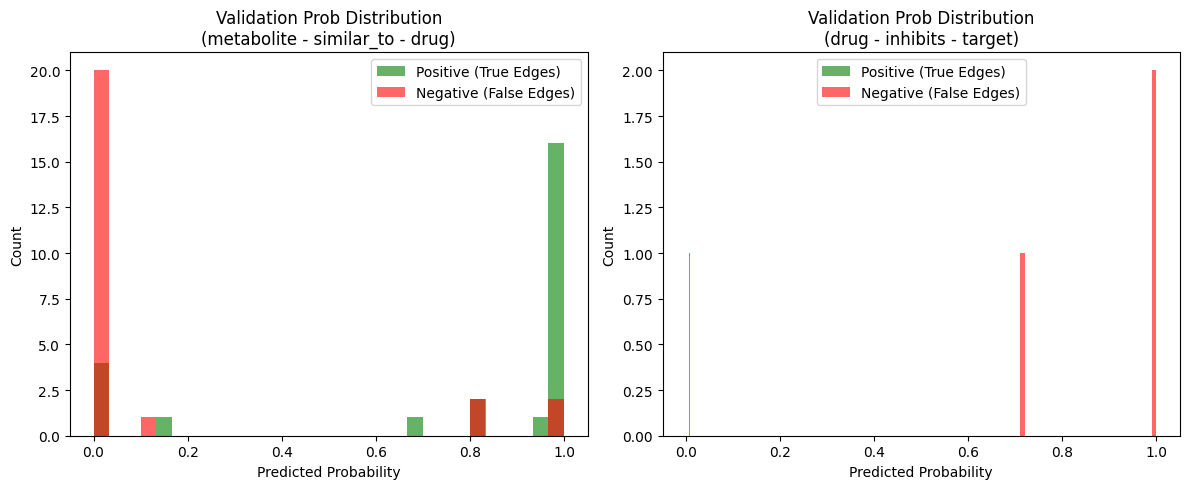

In [25]:
def plot_val_probability_distribution(model, loaders, edge_types, device):
    model.eval()
    
    plt.figure(figsize=(15, 4))
    
    for i, (loader, edge_type) in enumerate(zip(loaders, edge_types)):
        y_true_list = []
        y_prob_list = []
        
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                z_dict = model(batch)

                if edge_type not in batch.edge_types or not hasattr(batch[edge_type], 'edge_label_index'):
                    continue

                src_type, rel_type, dst_type = edge_type
                edge_label_index = batch[edge_type].edge_label_index
                edge_label = batch[edge_type].edge_label.float()

                logits = model.decode(z_dict, edge_label_index, src_type, dst_type)
                probs = torch.sigmoid(logits).cpu().numpy()
                labels = edge_label.cpu().numpy()
                
                y_true_list.extend(labels)
                y_prob_list.extend(probs)
                
        if len(y_true_list) == 0:
            continue
            
        y_true = np.array(y_true_list)
        probs = np.array(y_prob_list)
        
        plt.subplot(1, len(edge_types), i + 1)
        plt.hist(probs[y_true == 1], bins=20, alpha=0.5, label='Positive (True)', color='green')
        plt.hist(probs[y_true == 0], bins=20, alpha=0.5, label='Negative (False)', color='red')
        plt.title(f"Prob Dist: {edge_type[1]}")
        plt.xlabel("Predicted Probability")
        plt.ylabel("Frequency")
        plt.legend()
        
    plt.tight_layout()
    plt.show()

valid_val_edge_types = [et for et in TASK_EDGE_TYPES if et in val_data.edge_types and hasattr(val_data[et], 'edge_label_index')]
plot_val_probability_distribution(model, val_loader, valid_val_edge_types, DEVICE)\n